# Figure 1 - Overview of Spatial Scales

## Imports

In [27]:
# General libraries
import os
os.chdir("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/")
from pathlib import Path

# Plotting libraries
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
import matplotlib.patheffects as PathEffects
from matplotlib import gridspec
from matplotlib_scalebar.scalebar import ScaleBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# Data libraries
import numpy as np
import geopandas as gpd
import metpy.calc as mpcalc
from metpy.units import units

# Geospatial libraries
import rioxarray as rxr
import py3dep as py3d
import shapely.geometry as geom
from pynhd import NLDI, GeoConnex, WaterData
import xarray as xr
import pyproj
from shapely.geometry import LineString, Point
from shapely.ops import transform

## Data

### Functions

In [28]:
def get_topo(basin_geometry):
    """
    Retrieve topographic data for a given basin, including elevation, slope, and aspect.

    Parameters:
    -----------
    basin_geometry : geometry-like
        The basin geometry (e.g., a shapely polygon) defining the area of interest.
    data_path : Path
        The directory path where the topographic data will be saved (if save=True).
    save : bool, optional (default=True)
        If True, saves the retrieved topographic data as GeoTIFF files in the specified data_path.

    Returns:
    --------
    topo : dict
        A dictionary containing topographic datasets for the specified basin, including:
        - 'elevation': Digital Elevation Model (DEM).
        - 'slope_degrees': Slope in degrees.
        - 'aspect_degrees': Aspect in degrees.

    Notes:
    ------
    - The function retrieves topographic data using the `py3d.get_map` method.
    - The data is retrieved at a 30-meter resolution.
    - The source CRS is EPSG:4326, and the output CRS is EPSG:5070.
    - If `save=True`, the data is saved as GeoTIFF files in the given directory.
    """
    topo = py3d.get_map(["DEM", "Slope Degrees", "Aspect Degrees", "Hillshade Gray"], basin_geometry, 30, geo_crs=4326, crs=5070)
    return topo

### Geospatial

In [29]:
CWD = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/"
### Colorado River scale
ucrb_boundary = gpd.read_file(Path(f"{CWD}/01a_data_access/geodata/Upper_Colorado_River_Basin_Boundary.json", driver='GeoJSON'))
co_basin = gpd.read_file(Path(f"{CWD}/01a_data_access/geodata/CRB_HydroBounds.json", driver='GeoJSON'))

### East River scale
basin_boundary = gpd.read_file(Path(f"{CWD}/01a_data_access/geodata/East_River_lumped_HRUs_GRUs.shp"))
east_basin_bounds = basin_boundary.total_bounds
upper_east_river = gpd.read_file(Path(f"{CWD}/01a_data_access/geodata/upper_east_river.json", driver='GeoJSON'))

# Create points with CRS
gothic_point = gpd.GeoDataFrame(
    {'name': ['Gothic']},
    geometry=[Point(-106.987854, 38.956158)],
    crs='EPSG:4326'
)
kp_point = gpd.GeoDataFrame(
    {'name': ['Kettle Ponds']},
    geometry=[Point(-106.9209, 38.8591)],
    crs='EPSG:4326'
)
bb_point = gpd.GeoDataFrame(
    {'name': ['billy barr']},
    geometry=[Point(-106.99256, 38.96283)],
    crs='EPSG:4326'
)

# convert to 5070

upper_east_river = upper_east_river.to_crs(5070)
topo = get_topo(basin_boundary.geometry[0])

gothic_point = gothic_point.to_crs(5070)# Load DEM

kp_point = kp_point.to_crs(5070)

bb_point = bb_point.to_crs(5070)

# Flow lines

gauge_id = "09112500"  # USGS gauge ID for East Taylor River at Almont, CO
url = "https://api.water.usgs.gov/nldi/linked-data/wqp/USGS-09112500/navigation/UM/flowlines?distance=50&trimStart=false&trimTolerance=0.1"
flow_lines = gpd.read_file(url)

### Gridded data

In [30]:
# load ERA5 data
era5_ds = xr.open_dataset('/storage/dlhogan/precipitation-rodeo/data/external/ERA5-Land/era5_land_20211001_20230930.nc')
prism_ds = xr.open_dataset('/storage/dlhogan/precipitation-rodeo/data/external/PRISM/processed/prism_ppt_us_30s_20230930_clipped.nc')

lat_sel_5_by_5 = slice(39.5, 38.25)
lon_sel_5_by_5 = slice(-107.5, -106.5)


## Figure 
Broken up into components

### Functions

In [31]:
# Start designing a grid spec figure
def turn_off_spines(ax):
    """
    Turn off the spines of a given axis.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axis for which the spines
        should be turned off.
    """
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    return

### (A) East River basin

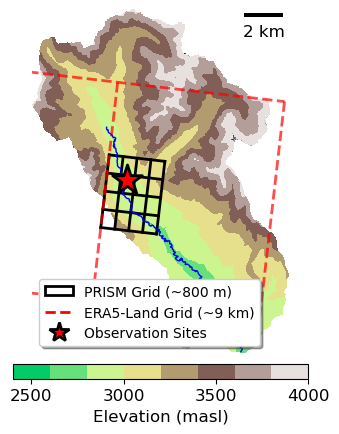

In [32]:
fig, ax = plt.subplots()
turn_off_spines(ax)

all_label_font_size = 16

# clip topo to upper east river boundary
topo = topo.rio.clip(upper_east_river.geometry.values, upper_east_river.crs, drop=True)

# clip flow lines to upper east river boundary
flow_lines = flow_lines.to_crs(upper_east_river.crs)
flow_lines = gpd.clip(flow_lines, upper_east_river)
# add dem to east dem
im0 = topo['hillshade_gray'].where(topo['elevation']>0).squeeze().plot(ax=ax, 
                                                                       cmap='gray', 
                                                                       vmin=0, 
                                                                       vmax=255,
                                                                       # turn off colorbar
                                                                       add_colorbar=False)
im1 = ax.contourf(
    topo.where(topo['elevation']>0).squeeze()['x'],
    topo.where(topo['elevation']>0).squeeze()['y'],
    topo['elevation'].where(topo['elevation']>0).squeeze(),
    cmap='terrain',
    vmin=2000,
    levels=np.arange(2400, 4100, 200),  # Reduced from 10 to 200 (from 170 to 9 levels)
)
# add red border around the basin
# upper_east_river.to_crs(5070).boundary.plot(ax=ax, 
#                                   color='red', 
#                                   linewidth=2, 
#                                   zorder=2)
# # add upper east river basin
# upper_east_river.plot(ax=ax, 
#                       color='grey',
#                       alpha=0.5, 
#                       zorder=2)
# # add the boundary
# upper_east_river.boundary.plot(ax=ax, 
#                                   color='black', 
#                                   linewidth=1, 
#                                   zorder=2)
# remove x and y labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('', fontsize=all_label_font_size, fontweight='bold')

flow_lines.to_crs(5070).plot(ax=ax,
                             color='blue', 
                             linewidth=1, 
                             zorder=3)

# add colorbar in top left corner half the length of the figure
cbar = plt.colorbar(im1, 
                    ax=ax, 
                    orientation='horizontal', 
                    # place on left side of the plot
                    location='bottom',
                    # make it the same height as the plot
                    fraction=0.04,
                    # aspect=30,
                    # change range to 2500 to 4001
                    # extend='both',
                    shrink=0.9,
                    pad=0.03)
# specify the colorbar ticks
cbar.set_ticks(np.arange(2500, 4001, 500))
# Set the colorbar tick labels
cbar.set_ticklabels([str(int(tick)) for tick in np.arange(2500, 4001, 500)], rotation=0)

# Set the colorbar label and font size
cbar.set_label('Elevation (masl)',
               fontsize=all_label_font_size-4)
# increase size of ticks and labels to 14
cbar.ax.tick_params(labelsize=all_label_font_size-4)

# add scale bar
scale3 = ScaleBar(
    dx=1,
    location='upper right',
    # label="Scale 3",
    font_properties={
        # "family": "serif",
        "size": all_label_font_size-4,
    },  # For more information, see the cell below
    scale_formatter=lambda value, unit: f"{value} {unit}",
)
ax.add_artist(scale3,
)


# 1. Extract lat/lon from PRISM & ERA5-Land and filter to basin center
# Get the centroid of the upper east river basin (in WGS84)
basin_centroid = upper_east_river.to_crs(4326).geometry.values[0].centroid
center_lon, center_lat = basin_centroid.x, basin_centroid.y

# Get all lat/lon values
all_lats = prism_ds.lat.values
all_lons = prism_ds.lon.values
all_lons = np.where(all_lons > 180, all_lons - 360, all_lons)  # convert 0–360 to -180–180

# Find indices of closest lat/lon to the basin center
lat_idx = np.argmin(np.abs(all_lats - center_lat))
lon_idx = np.argmin(np.abs(all_lons - center_lon))

# Shift center: 2 boxes down (south/higher lat index) and 2 boxes left (west/lower lon index)
lat_idx = lat_idx - 2
lon_idx = lon_idx - 2

# Select 5 grid boxes (2 on each side of center, plus center = 5 total in each direction)
n_boxes = 2  # boxes on each side of center
lats = all_lats[max(0, lat_idx-n_boxes):min(len(all_lats), lat_idx+n_boxes+1)]
lons = all_lons[max(0, lon_idx-n_boxes):min(len(all_lons), lon_idx+n_boxes+1)]

# 2. Create pyproj transformer from WGS84 to EPSG:5070
project = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True).transform

# 3. Plot lat lines (horizontal grid lines)
for i, lat in enumerate(lats):
    line = LineString(zip(lons, [lat] * len(lons)))
    line_proj = transform(project, line)
    x, y = line_proj.xy
    ax.plot(x, y, color='black', linewidth=2, zorder=1)

# 4. Plot lon lines (vertical grid lines)
for j, lon in enumerate(lons):
    line = LineString(zip([lon] * len(lats), lats))
    line_proj = transform(project, line)
    x, y = line_proj.xy
    ax.plot(x, y, color='black', linewidth=2, zorder=1)

# 4b. Add ERA5-Land grid lines with different color
# Get ERA5 lat/lon values
era5_all_lats = era5_ds.latitude.values
era5_all_lons = era5_ds.longitude.values
era5_all_lons = np.where(era5_all_lons > 180, era5_all_lons - 360, era5_all_lons)

# Find indices closest to basin center for ERA5
era5_lat_idx = np.argmin(np.abs(era5_all_lats - center_lat))
era5_lon_idx = np.argmin(np.abs(era5_all_lons - center_lon))

# Shift center same as PRISM

# Select ERA5 grid boxes (only 3 boxes: 1 on each side of center, plus center)
era5_n_boxes = 1  # 1 box on each side = 3 total boxes
era5_lats = era5_all_lats[max(0, era5_lat_idx-era5_n_boxes):min(len(era5_all_lats), era5_lat_idx+era5_n_boxes+1)]
era5_lons = era5_all_lons[max(0, era5_lon_idx-era5_n_boxes):min(len(era5_all_lons), era5_lon_idx+era5_n_boxes+1)]

# Only plot if we have at least 2 points (needed to create a LineString)
if len(era5_lats) >= 2 and len(era5_lons) >= 2:
    # Plot ERA5 lat lines (horizontal grid lines) in different color
    for i, lat in enumerate(era5_lats):
        line = LineString(zip(era5_lons, [lat] * len(era5_lons)))
        line_proj = transform(project, line)
        x, y = line_proj.xy
        ax.plot(x, y, color='red', linewidth=2, linestyle='--', zorder=1, alpha=0.7)

    # Plot ERA5 lon lines (vertical grid lines)
    for j, lon in enumerate(era5_lons):
        line = LineString(zip([lon] * len(era5_lats), era5_lats))
        line_proj = transform(project, line)
        x, y = line_proj.xy
        ax.plot(x, y, color='red', linewidth=2, linestyle='--', zorder=1, alpha=0.7)

# 5. Plot gothic and kp points with stars and arrows
# Import necessary items for legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Plot the points as stars
gothic_star = ax.scatter(gothic_point.geometry.x, gothic_point.geometry.y, 
                         marker='*', s=500, color='red', edgecolors='black', 
                         linewidths=2, zorder=10, label='Observation Sites')
# kp_star = ax.scatter(kp_point.geometry.x, kp_point.geometry.y, 
#                          marker='*', s=250, color='red', edgecolors='black', 
#                          linewidths=2, zorder=10, label='Observation Sites')
# billy_barr_star = ax.scatter(bb_point.geometry.x, bb_point.geometry.y,
#                          marker='*', s=250, color='red', edgecolors='black',
#                          linewidths=2, zorder=10, label='Observation Sites')

# 6. Add legend
# Create custom legend elements
legend_elements = [
    Patch(facecolor='none', edgecolor='black', linewidth=2, label='PRISM Grid (~800 m)'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='ERA5-Land Grid (~9 km)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', 
           markeredgecolor='black', markeredgewidth=2, markersize=15, label='Observation Sites'),
    # Patch(facecolor='none', edgecolor='red', linewidth=2, label='Basin Boundary')
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=all_label_font_size-6, 
         frameon=True, fancybox=True, shadow=True)

# save as high resolution png

## Appendix

### UCRB-wide region

AttributeError: 'numpy.ndarray' object has no attribute 'geometry'

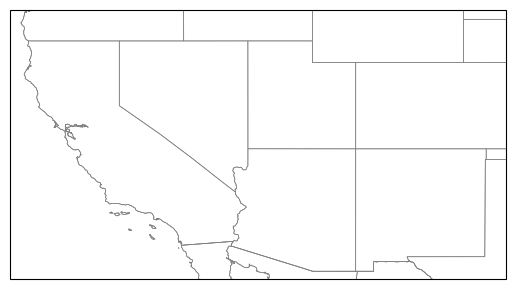

In [33]:
# add ucrb boundary and convert to lcc projection 
# plot the UCRB boundary
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
# create cartopy map of US states
ax.set_extent([co_basin.total_bounds[0]-6,
                       co_basin.total_bounds[2],
                       co_basin.total_bounds[1],
                       co_basin.total_bounds[3]], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='grey', linewidth=0.5)
ax.add_feature(cfeature.STATES,edgecolor='grey', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# label the Western US
# ax.set_title('Western US', fontsize=16, fontweight='bold')
# add a star for the center of the east river boundary
center = east_basin_bounds.geometry.values[0].centroid
ax.plot(center.x, center.y, marker='*', color='red', markersize=10, transform=ccrs.PlateCarree(), zorder=3)

# plot the CRB boundary
co_basin.iloc[6:].plot(ax=ax, color='blue', linewidth=1.5, zorder=2, transform=ccrs.PlateCarree(), alpha=0.3)
# annotate the CRB boundary
ax.text(co_basin.dissolve().centroid.values[0].x-1, 
        co_basin.dissolve().centroid.values[0].y, 
        'CRB', 
        fontsize=14, 
        fontweight='bold', 
        transform=ccrs.PlateCarree(), 
        zorder=4)
# save
fig.savefig('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/for_manuscript/western_us_map.png',
            dpi=300,
            bbox_inches='tight',
            transparent=False)

### Grid-spec figure creation

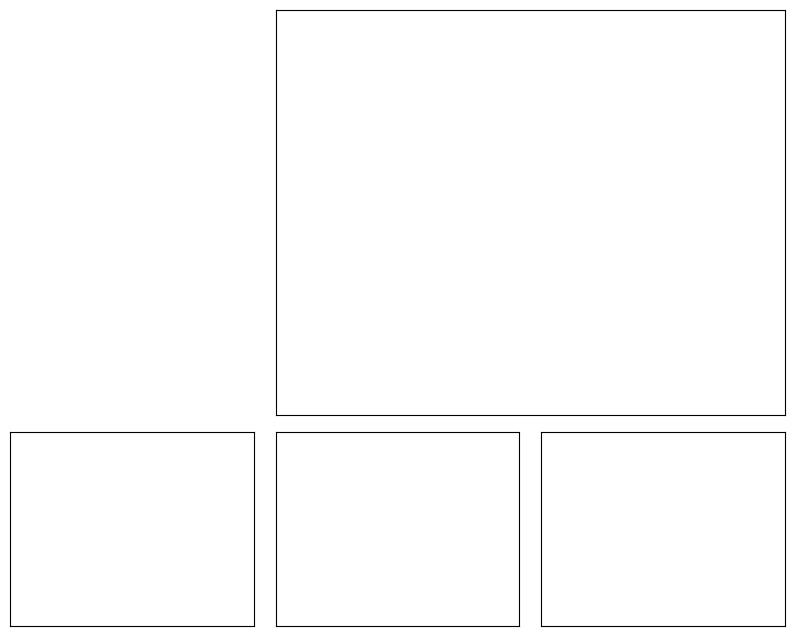

In [ ]:

# Create a grid spec figure
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 6, width_ratios=[1, 1, 1, 1, 1, 1])

ax_valley = plt.subplot(gs[0:4, 2:])
ax_avery = plt.subplot(gs[4:6, 0:2])
ax_gothic = plt.subplot(gs[4:6, 2:4])
ax_kp = plt.subplot(gs[4:6, 4:6])

ax_west_us = plt.subplot(gs[2:4, 0:2], projection=ccrs.LambertConformal(),
                      frameon=False)
ax_east_dem = plt.subplot(gs[0:3, 1:3], 
                        frameon=False)

# make the background transparent
ax_east_dem.set_facecolor('none')
# turn off spines
turn_off_spines(ax_east_dem)

# turn off labels 
ax_valley.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_gothic.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_avery.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kp.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

/tmp/ipykernel_692762/2584124648.py:68: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ax_west_us.text(co_basin.dissolve().centroid.values[0].x-1, co_basin.dissolve().centroid.values[0].y, 'CRB', fontsize=14, fontweight='bold', transform=ccrs.PlateCarree(), zorder=4)
/tmp/ipykernel_692762/2584124648.py:68: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ax_west_us.text(co_basin.dissolve().centroid.values[0].x-1, co_basin.dissolve().centroid.values[0].y, 'CRB', fontsize=14, fontweight='bold', transform=ccrs.PlateCarree(), zorder=4)


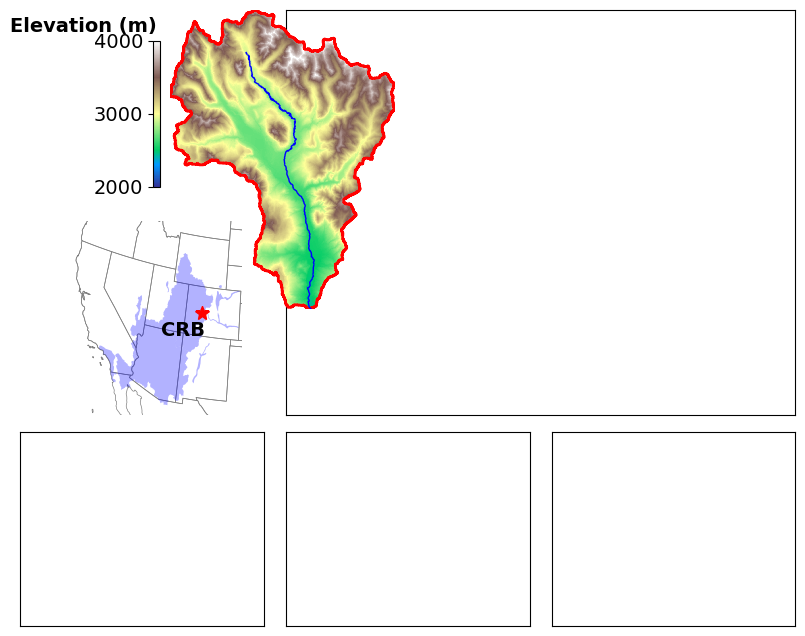

<Figure size 640x480 with 0 Axes>

In [ ]:
# add dem to east dem
im0 = topo['hillshade_gray'].where(topo['elevation']>0).squeeze().plot(ax=ax_east_dem, 
                                                                       cmap='gray', 
                                                                       vmin=0, 
                                                                       vmax=255,
                                                                       # turn off colorbar
                                                                       add_colorbar=False)
im1 = topo['elevation'].where(topo['elevation']>0).squeeze().plot(ax=ax_east_dem, 
                                                                  cmap='terrain', 
                                                                  vmin=2000, 
                                                                  vmax=4000,
                                                                  add_colorbar=False,)
# add red border around the basin
east_basin_bounds.to_crs(5070).boundary.plot(ax=ax_east_dem, 
                                  color='red', 
                                  linewidth=2, 
                                  zorder=2)
# add scale bar 


# remove x and y labels
ax_east_dem.set_xlabel('')
ax_east_dem.set_ylabel('')
ax_east_dem.set_title('', fontsize=16, fontweight='bold')

flow_lines.to_crs(5070).plot(ax=ax_east_dem,
                             color='blue', 
                             linewidth=1, 
                             zorder=3)
# add colorbar in top left corner half the length of the figure
cbar = plt.colorbar(im1, 
                    ax=ax_east_dem, 
                    # set limits to 2500 to 4000
                    orientation='vertical', 
                    location='left',
                    fraction=0.03,
                    anchor=(0,0.8),
                    pad=0.04)
cbar.ax.set_title('Elevation (m)',
               fontsize=14, 
               fontweight='bold',
               ha='right',)
# increase size of ticks and labels to 14
cbar.ax.tick_params(labelsize=14)


# add ucrb boundary and convert to lcc projection 
# plot the UCRB boundary

# create cartopy map of US states
ax_west_us.set_extent([co_basin.total_bounds[0]-6,
                       co_basin.total_bounds[2],
                       co_basin.total_bounds[1],
                       co_basin.total_bounds[3]], crs=ccrs.PlateCarree())
ax_west_us.add_feature(cfeature.BORDERS, edgecolor='grey', linewidth=0.5)
ax_west_us.add_feature(cfeature.STATES,edgecolor='grey', linewidth=0.5)
ax_west_us.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# label the Western US
# ax_west_us.set_title('Western US', fontsize=16, fontweight='bold')
# add a star for the center of the east river boundary
center = east_basin_bounds.geometry.values[0].centroid
ax_west_us.plot(center.x, center.y, marker='*', color='red', markersize=10, transform=ccrs.PlateCarree(), zorder=3)

# plot the CRB boundary
co_basin.plot(ax=ax_west_us, color='blue', linewidth=1.5, zorder=2, transform=ccrs.PlateCarree(), alpha=0.3)
# annotate the CRB boundary
ax_west_us.text(co_basin.dissolve().centroid.values[0].x-1, co_basin.dissolve().centroid.values[0].y, 'CRB', fontsize=14, fontweight='bold', transform=ccrs.PlateCarree(), zorder=4)

fig